In [1]:
import os
import json
from time import time

# using async memory allocator to avoid some cuda allocation errors
# see: https://docs.nvidia.com/deeplearning/frameworks/tensorflow-user-guide/index.html
os.environ['TF_GPU_ALLOCATOR']='cuda_malloc_async'
# and turning off debugging info to clean up output during final run
os.environ['TF_CPP_MIN_LOG_LEVEL']='3'

# the "noqa: E402" comments below are to stop the linting tool I'm using from picking these up as not being at top of file
# this has been done as the above env. variables need to be set before we import tensorflow
import tensorflow as tf  # noqa: E402
import keras_tuner as kt  # noqa: E402

from modules.datastore import load_datasets,save_hp_search,load_hp_searches  # noqa: E402
from modules.helper_functions import display_samples,eval_model,show_incorrect_predictions  # noqa: E402
from modules.model_constructor import CustomHyperModel  # noqa: E402

# setting matplot so it renders in the notebook
%matplotlib inline

# we also want to use mixed precision so
tf.keras.mixed_precision.set_global_policy(tf.keras.mixed_precision.Policy('mixed_float16'))

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3090, compute capability 8.6


In [2]:
# first set some initial data up
dataset_path='datasets/CompositeDS/'
class_map = {0:"Original", 1:"Poisoned"}

# we need to remove any corrupted images
# see: https://stackoverflow.com/questions/57674314/images-png-jpg-or-jpeg-is-detected-as-corrupt-with-pythons-pil-pillow-veri

# set the batch size and image resolution as we'll keep these static
batch_size=64
image_resolution=512

Generating preview for train dataset, which contains ~14016 samples:


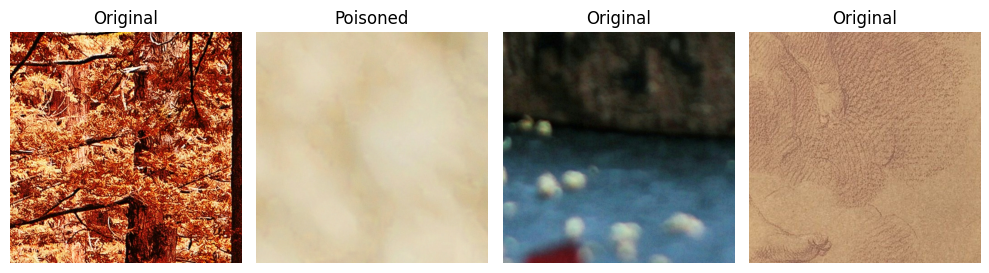

Generating preview for validation dataset, which contains ~3008 samples:


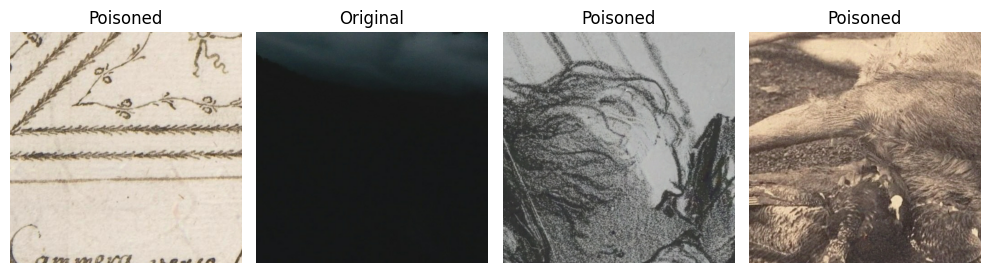

Generating preview for test dataset, which contains ~3008 samples:


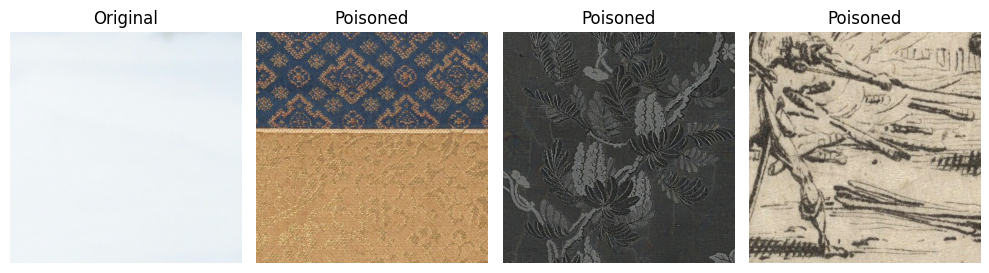

In [3]:
# let's test loading our dataset by generating a preview for each dataset
ds = load_datasets(dataset_path, batch_size, image_resolution)
for n, d in ds.items():
    print(f"Generating preview for {n} dataset, which contains ~{len(d)*batch_size} samples:")
    display_samples(d,class_map,grid_shape=(1,4))

In [4]:
# we don't want to have to retype all this for each trial so we need something that can be called for various hp search algorithms, image sizes and resizing methods
def run_trials(train_ds, val_ds, max_epochs, image_size, tuner_args):
    """
    For a given hyperparameter optimisation algorithm, image size and resizing method will run a hyperparameter search and save the results to the models\search_results folder.
    
    Results will be stored in csv format with name in format "{search_algo}_size{image_size}_crop{crop_and_pad}.csv".
    
    Args:
        train_ds (TF Dataset): TensorFlow dataset for training
        val_ds (TF Dataset): TensorFlow dataset for validation
        max_epochs (int): maximum number of epochs for each trial
        image_size (int): maximum height/width of the images
        tuner_args (dict): dictionary with kwargs for tuner object
    """    
    # start a timer so we can review execution time
    start = time()
    
    # set up our tuner with kwargs passed to run_trials
    tuner = kt.BayesianOptimization(**tuner_args)

    # set up the callback for early stopping
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=1e-3, patience=5)
    ]

    # and then begin the search
    tuner.search(
        train_ds,
        epochs=max_epochs,
        callbacks=[callbacks],
        validation_data=val_ds
    )
    
    # calculate the runtime
    runtime = time() - start
    
    # lastly we'll save the top 20 results and update the comparison file needed
    save_hp_search(tuner,runtime,num_to_save=20,save_folder='results')

Before running anything we want to check how long it's going to take and tweak until we're expecting runtime <48 hours. This likely a pessimistic estimate due to our use of early stopping and skipping over large models.

We have six different searches to run, three with hyperband and three with bayesian optimisation so we calculate how long they'll take approximately with the below then tweak values as required.

In [5]:
# bayesian optimisation
# https://keras.io/api/keras_tuner/tuners/bayesian/#bayesianoptimization-class
max_epochs=15
max_trials=75
expected_epochs=max_epochs*max_trials
runtime_seconds=expected_epochs*300

print(f"Bayesian optimisation will run for a maximum of {expected_epochs} epochs.")
print(f"This is expected to take no more than {runtime_seconds/60/60} hours.")

Bayesian optimisation will run for a maximum of 1125 epochs.
This is expected to take no more than 93.75 hours.


Now we've got a method for running trials, and a reasonable estimate for the time frame, we want to create a combination of searches we can run.

For completeness we want to test:

• bayesopt + hyperband

• sample sizes of either 512x512 or 256x256

• resizing methods of either crop and pad or resize via nearest neighbour

Since the source data is not cropped, padded or resized if the desired image size is the same as the source data we also want to avoid testing both crop and pad and resize for 512x512 images!

In [6]:
# set up the options for the hypertuner
tuner_args = {
    "hypermodel": CustomHyperModel(input_shape=(image_resolution,image_resolution) + (3,)),
    "objective": 'val_accuracy',
    "max_trials": max_trials,
    "max_model_size": 4e6, # added this to try and avoid us ending up with oversized models and OOM errors            
    #"num_initial_points": 15, # num_initial_points defaults to 3x the dimensionality of the model, that's 33 trials in our case!
    "beta": 3.,
    #"seed": 123, # added seed during testing for consistency
    "max_retries_per_trial": 2, # we'll retry a few times but these are probably memory errors
    "max_consecutive_failed_trials": 10, # set at 10 as trials skipped due to max_model_size contribute to this counter!
    "directory": 'autotune',
    "project_name": 'final_run'
}

# now we can run our trials, we'll also keep a record of how long each took
run_trials(ds['train'], ds['validation'], max_epochs, image_resolution, tuner_args)

Compiled model with 42569 parameters.
Compiled model with 389193 parameters.
Compiled model with 274505 parameters.
Compiled model with 653897 parameters.

Search: Running Trial #1

Value             |Best Value So Far |Hyperparameter
6.4e-07           |6.4e-07           |learning_rate
32                |32                |conv1_filters
True              |True              |residual_connections
1                 |1                 |block_repetitions
320               |320               |block_1_filters
640               |640               |final_conv_filters
0.25              |0.25              |dropout

Compiled model with 342113 parameters.
Epoch 1/15


I0000 00:00:1720747781.938186   20814 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 43/219 [====>.........................] - ETA: 3:51 - loss: 0.7237 - accuracy: 0.4964

Now let's load and take a peek at our results. Whilst doing this we'll get the best model from each trial for further training.

In [ ]:
# load the results and set up a dict to store the best from each trial
results = load_hp_searches(load_folder='results/search_results/',metric='val_accuracy')
best_results = {}

# now iterate over the results, this will be in best -> worst order so we can populate best_results as we go
print('Make sure we have all the results loaded:')
for result in results:
    if result['trial'] not in best_results.keys():
        best_results.update({result['trial']:result})
    print(f"{result['trial']}, {result['val_accuracy']}")

# print out the best_results for each trial
print('\nBest result for each trial:')
for k,v in best_results.items():
    print(k,v['val_accuracy'])

Now we can take the best results and see if we can load a model from the hyperparameters specified within.

In [ ]:
def load_from_trial(trial_data):
    # determine the image size and resize method from the filename
    image_size = 512 if '512' in trial_data['trial'] else 256
    crop_and_pad = True if 'cropTrue' in trial_data['trial'] else False
    # load the dataset
    ds = load_datasets(dataset_path, batch_size, image_size, crop_and_pad)
    # now filter the trial_data to get what we need and convert the hyperparameters to the correct datatype
    params = {
        'learning_rate': float(trial_data['learning_rate']),
        'flip_augmentation': bool(trial_data['flip_augmentation']),
        'rotate_augmentation': bool(trial_data['rotate_augmentation']),
        'conv1_filters': int(trial_data['conv1_filters']),
        'residual_connections': bool(trial_data['residual_connections']),
        'block_repetitions': int(trial_data['block_repetitions']),
        'block_1_filters': int(trial_data['block_1_filters']),
        # some of these may be empty strings, or may not exist, so need to check first
        'block_2_filters': None if int(trial_data['block_repetitions'])<2 else int(trial_data['block_2_filters']),
        'block_3_filters': None if int(trial_data['block_repetitions'])<3 else int(trial_data['block_3_filters']),
        'final_conv_filters': int(trial_data['final_conv_filters']),
        'dropout': float(trial_data['dropout'])
    }
    # print the details of the model before we build it
    print(f"\nLoading model from trial {trial_data['trial']}.")
    print(f"Parameters:\n{params}")
    # lastly we can use CustomHyperModel to build a model for us
    hypermodel = CustomHyperModel(input_shape=(image_size,image_size) + (3,))
    model = hypermodel.model_builder(**params)
    return ds, model

For the best four results we're going to:

 • create a model with the associated hyperparameters;

 • train the model until it stops improving
 
 • checkpointing the model if its the best seen thus far;

 • reload the best performing checkpoint and evaluate against the validation and test datasets; and
 
 • finally save our training history to a file.

In [ ]:
# first create a dict to store our results in
training_results = {}

for trial_name, trial_data in best_results.items():
    # load the dataset and create the model
    ds, model = load_from_trial(trial_data)
    if not (os.path.exists(f'results/models/{trial_name}/{trial_name}.keras') and os.path.exists(f'results/models/{trial_name}/{trial_name}_history.json')):
        # this time we're not going to stop early, we'll train each model to 40 epochs and save the best checkpoint
        callbacks = [
            tf.keras.callbacks.ModelCheckpoint(
                f'results/models/{trial_name}/{trial_name}.keras',
                monitor='val_loss',
                mode='min',
                save_best_only=True
            )
        ]
        # train the model and save the history, we'll set the max epochs such that early stopping should kick in
        history = model.fit(
            ds['train'],
            epochs=40,
            verbose=0,
            callbacks=callbacks,
            validation_data=ds['validation'],
        ).history
        #now save the history
        json.dump(history, open(f'results/models/{trial_name}/{trial_name}_history.json', 'w'), indent="\t")
    else:
        print(f'\nModel_{trial_name} already exists, proceeding to load model and history from file.\n')
    # reload the model and history (or load if the directory already existed) from checkpoint
    model = tf.keras.models.load_model(f'results/models/{trial_name}/{trial_name}.keras')
    history = json.load(open(f'results/models/{trial_name}/{trial_name}_history.json', 'r'))
    # save a visualisation of the model for use in our report
    tf.keras.utils.plot_model(model,show_shapes=True,to_file=f'results/models/{trial_name}/{trial_name}.png')
    # generate a textual model summary (useful as it has params per layer)
    print(f'Summary of model_{trial_name}:')
    model.summary()
    # print the history and evaluate the model
    evaluation = eval_model(trial_name,model,history,ds['validation'],ds['test'])
    # put the evaluation results into the dict we created earlier
    training_results.update({trial_name:evaluation})

# save all of the results for review in external program(s)
json.dump(training_results, open('results/training_results.json', 'w'), indent="\t")

In [ ]:
# now for each trial in best results reload the model and display some predictions
for trial_name, trial_data in best_results.items():
    # we don't actually need to reload the model here... need to fix in refactor
    ds, model = load_from_trial(trial_data)
    # reload the model and history (or load if the directory already existed) from checkpoint
    model = tf.keras.models.load_model(f'results/models/{trial_name}/{trial_name}.keras')
    show_incorrect_predictions(model, ds['test'], class_map)